# Embedding similarity over time

Load face embeddings from `embeddings.npy`, compute **cosine similarity** for each pair of consecutive embedding vectors, and plot similarity over time (frame index).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Path to the embeddings file (change if needed)
EMBEDDINGS_PATH = "embeddings.npy"

In [2]:
# Load embeddings: shape (N, embedding_dim)
embeddings = np.load(EMBEDDINGS_PATH)
n_frames, dim = embeddings.shape
print(f"Loaded {n_frames} embeddings, dimension {dim}")

Loaded 3977 embeddings, dimension 512


In [3]:
# Cosine similarity for consecutive pairs: sim[i] = cos(emb[i], emb[i+1])
# cos(a, b) = dot(a, b) / (norm(a) * norm(b))

def cosine_similarity_consecutive(emb):
    """Compute cosine similarity between consecutive rows of emb. Returns array of length N-1."""
    a = emb[:-1]   # all but last
    b = emb[1:]    # all but first
    dot = np.sum(a * b, axis=1)
    norm_a = np.linalg.norm(a, axis=1)
    norm_b = np.linalg.norm(b, axis=1)
    return dot / (norm_a * norm_b)

similarities = cosine_similarity_consecutive(embeddings)
print(f"Computed {len(similarities)} consecutive-pair similarities")
print(f"Range: [{similarities.min():.4f}, {similarities.max():.4f}], mean: {similarities.mean():.4f}")

Computed 3976 consecutive-pair similarities
Range: [0.7954, 0.9992], mean: 0.9640


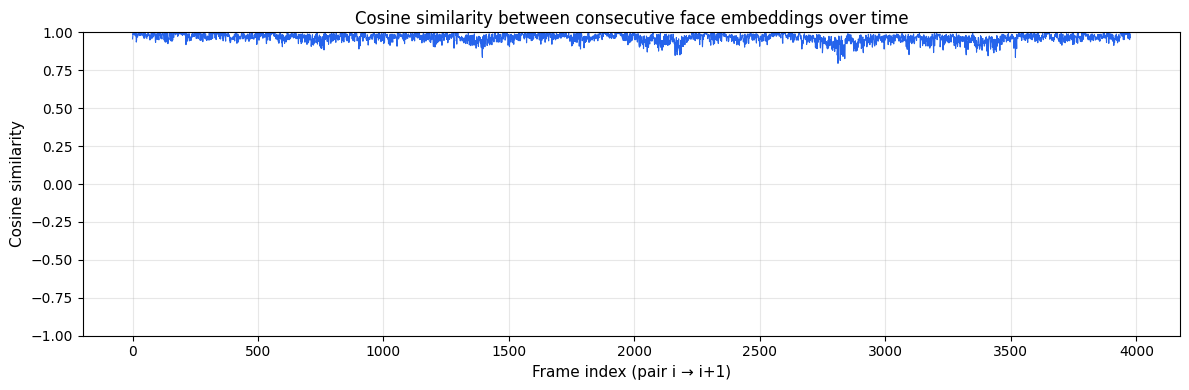

In [4]:
# Plot: x = frame index (pair i → i+1), y = cosine similarity
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(similarities))  # 0, 1, ..., N-2
ax.plot(x, similarities, linewidth=0.8, color="#2563eb")
ax.set_xlabel("Frame index (pair i → i+1)", fontsize=11)
ax.set_ylabel("Cosine similarity", fontsize=11)
ax.set_title("Cosine similarity between consecutive face embeddings over time")
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()